In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Attention, Concatenate
from tensorflow.keras.models import Model

In [2]:
# LOAD DATA

vocab_size = 10000
max_len = 100

(X_train, y_train), _ = imdb.load_data(num_words=vocab_size)
X_train = pad_sequences(X_train, maxlen=max_len)

# Convert labels to sequence (for Seq2Seq style)
y_seq = np.repeat(y_train.reshape(-1,1), max_len, axis=1)
y_seq = np.expand_dims(y_seq, -1)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# ENCODER
encoder_inputs = Input(shape=(max_len,))
encoder_embed = Embedding(vocab_size, 64)(encoder_inputs)

encoder_lstm = LSTM(64, return_sequences=True, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(encoder_embed)

In [4]:
# DECODER
decoder_inputs = Input(shape=(max_len,1))
decoder_lstm = LSTM(64, return_sequences=True)
decoder_outputs = decoder_lstm(decoder_inputs, initial_state=[state_h, state_c])

In [5]:
# ATTENTION
attention_layer = Attention()
attention_output = attention_layer([decoder_outputs, encoder_outputs])

# Combine
concat = Concatenate()([decoder_outputs, attention_output])

In [6]:
# Final output
dense = Dense(1, activation='sigmoid')
final_output = dense(concat)

In [7]:
# MODEL
model = Model([encoder_inputs, decoder_inputs], final_output)
model.compile(optimizer='adam', loss='binary_crossentropy')

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 64)   │    640,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 100, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 100, 64), │     33,024 │ embedding[0][0]   │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 100, 64)   │     16,896 │ input_layer_1[0]… │
│                     │                   │            │ lstm[0][1],       │
│                     │                   │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 100, 64)   │          0 │ lstm_1[0][0],     │
│ (Attention)         │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100, 128)  │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 100, 1)    │        129 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 690,049 (2.63 MB)

 Trainable params: 690,049 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# TRAIN
model.fit([X_train, y_seq], y_seq, epochs=3, batch_size=64)

Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 70s 180ms/step - loss: 0.0624
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 68s 173ms/step - loss: 0.0101
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 68s 174ms/step - loss: 0.0039


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step


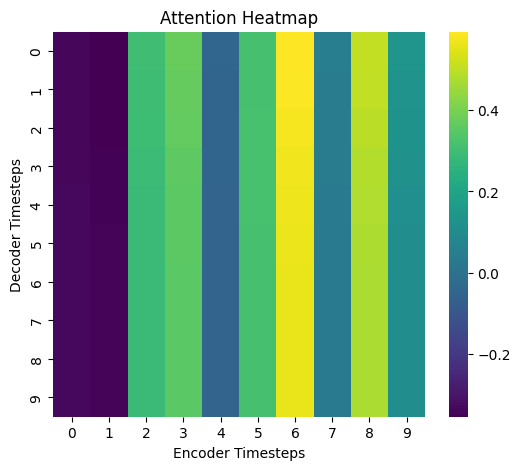

In [10]:
# ATTENTION HEATMAP

# Take one sample
sample_input = X_train[:1]
sample_target = y_seq[:1]

# Create sub-model to extract attention output
attention_model = Model(
    inputs=model.input,
    outputs=attention_output
)

attention_weights = attention_model.predict([sample_input, sample_target])

# Reduce dimensions for visualization
attention_map = attention_weights[0]

plt.figure(figsize=(6,5))
sns.heatmap(attention_map[:10, :10], cmap='viridis')

plt.title("Attention Heatmap")
plt.xlabel("Encoder Timesteps")
plt.ylabel("Decoder Timesteps")

plt.show()